# Aman shukla - MSC AI ML 2
# Practical Assignment 1
# Roll NO 21


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Dataset 1

In [44]:
data = {
    "Distance":[576,370,612,1216,409,1502,946,998,189,787,210,737],
    "Airfare":[178,138,94,278,158,258,198,188,98,179,138,98]
}

df = pd.DataFrame(data)
df

,Distance,Airfare
0,576,178
1,370,138
2,612,94
3,1216,278
4,409,158
5,1502,258
6,946,198
7,998,188
8,189,98
9,787,179


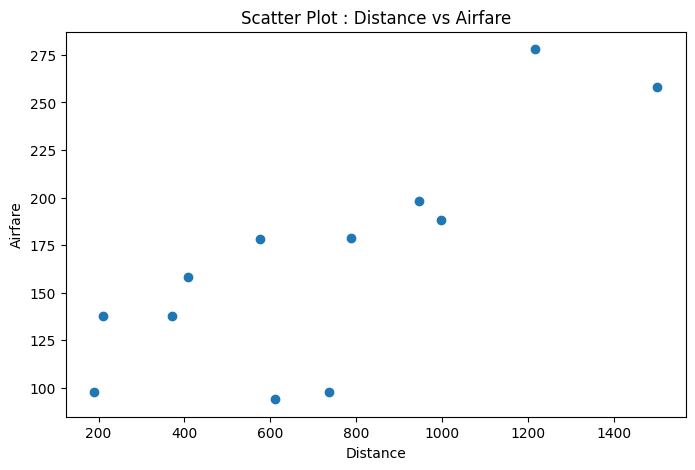

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(df["Distance"], df["Airfare"])

plt.xlabel("Distance")
plt.ylabel("Airfare")
plt.title("Scatter Plot : Distance vs Airfare")

plt.show()

In [4]:
x = df["Distance"].values
y = df["Airfare"].values

x_mean = np.mean(x)
y_mean = np.mean(y)

a1 = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)
a0 = y_mean - a1*x_mean

print("Slope (a1):", a1)
print("Intercept (a0):", a0)

Slope (a1): 0.11737508839231388
Intercept (a0): 83.26735367241098


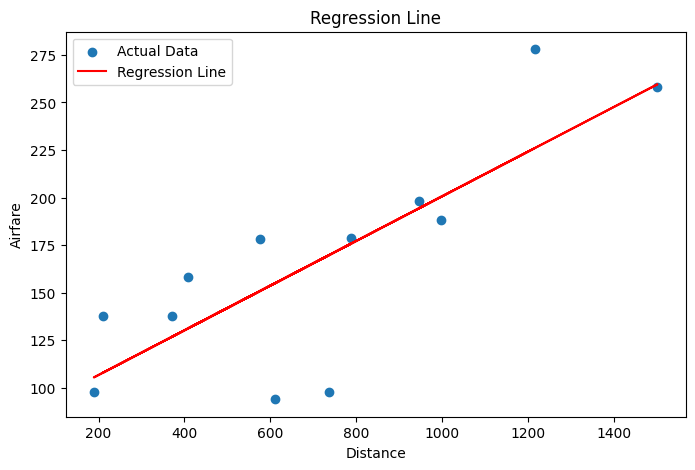

In [5]:
y_pred = a0 + a1*x

plt.figure(figsize=(8,5))
plt.scatter(x,y,label="Actual Data")
plt.plot(x,y_pred,color='red',label="Regression Line")

plt.xlabel("Distance")
plt.ylabel("Airfare")
plt.title("Regression Line")

plt.legend()
plt.show()

In [6]:
SSE = np.sum((y - y_pred)**2)
print("SSE =", SSE)

SSE = 14308.837785527729


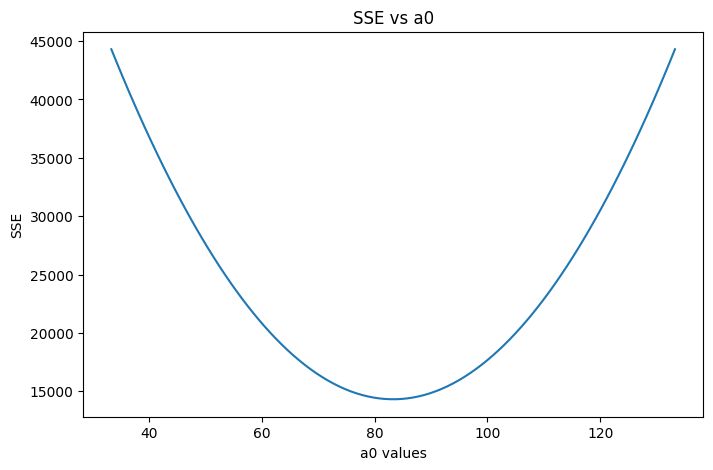

In [7]:
a0_values = np.linspace(a0-50, a0+50, 100)
sse_a0 = []

for i in a0_values:
    y_temp = i + a1*x
    sse = np.sum((y - y_temp)**2)
    sse_a0.append(sse)

plt.figure(figsize=(8,5))
plt.plot(a0_values, sse_a0)

plt.xlabel("a0 values")
plt.ylabel("SSE")
plt.title("SSE vs a0")

plt.show()

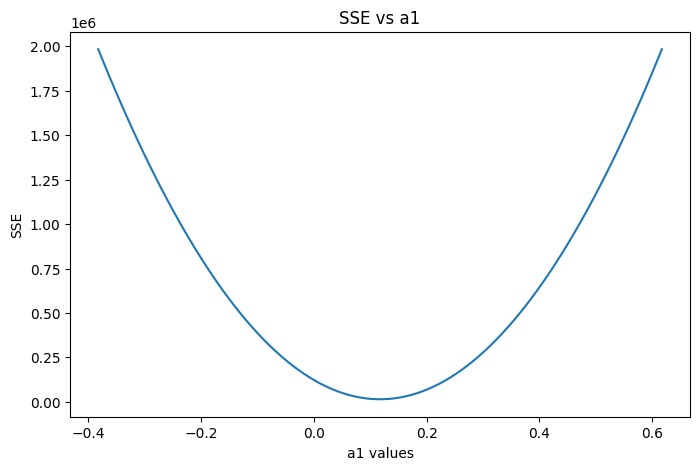

In [8]:
a1_values = np.linspace(a1-0.5, a1+0.5, 100)
sse_a1 = []

for i in a1_values:
    y_temp = a0 + i*x
    sse = np.sum((y - y_temp)**2)
    sse_a1.append(sse)

plt.figure(figsize=(8,5))
plt.plot(a1_values, sse_a1)

plt.xlabel("a1 values")
plt.ylabel("SSE")
plt.title("SSE vs a1")

plt.show()


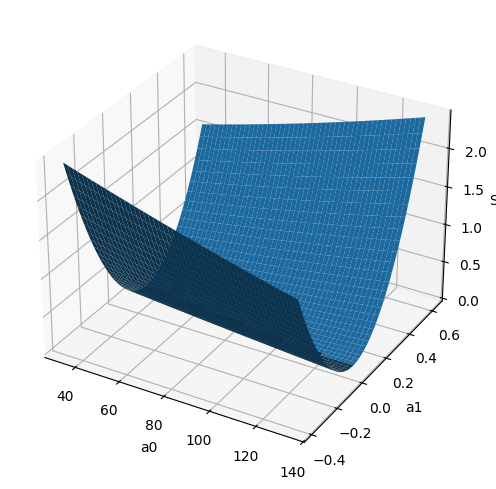

In [9]:
from mpl_toolkits.mplot3d import Axes3D

a0_range = np.linspace(a0-50, a0+50, 50)
a1_range = np.linspace(a1-0.5, a1+0.5, 50)

A0, A1 = np.meshgrid(a0_range, a1_range)
SSE_surface = np.zeros(A0.shape)

for i in range(len(a0_range)):
    for j in range(len(a1_range)):
        y_temp = A0[i,j] + A1[i,j]*x
        SSE_surface[i,j] = np.sum((y - y_temp)**2)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(A0, A1, SSE_surface)

ax.set_xlabel('a0')
ax.set_ylabel('a1')
ax.set_zlabel('SSE')

plt.show()

In [10]:
a0_gd = 0
a1_gd = 0

learning_rate = 0.000001
epochs = 1000
n = len(x)

for i in range(epochs):

    y_pred = a0_gd + a1_gd*x

    da0 = (-2/n) * np.sum(y - y_pred)
    da1 = (-2/n) * np.sum((y - y_pred)*x)

    a0_gd = a0_gd - learning_rate*da0
    a1_gd = a1_gd - learning_rate*da1

print("Gradient Descent a0:", a0_gd)
print("Gradient Descent a1:", a1_gd)

Gradient Descent a0: 0.03792106598408341
Gradient Descent a1: 0.2077201761386623


In [11]:
X = np.vstack([np.ones(len(x)), x]).T

beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("Matrix Method a0:", beta[0])
print("Matrix Method a1:", beta[1])

Matrix Method a0: 83.26735367241099
Matrix Method a1: 0.11737508839231384


In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

x_reshape = x.reshape(-1,1)
model.fit(x_reshape,y)

print("Library Intercept:", model.intercept_)
print("Library Slope:", model.coef_[0])

Library Intercept: 83.26735367241098
Library Slope: 0.11737508839231386


In [13]:
y_pred_lib = model.predict(x_reshape)

mse = mean_squared_error(y, y_pred_lib)
mae = mean_absolute_error(y, y_pred_lib)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_lib)

print("R2 Score:", r2)
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.6320019429562409
MSE: 1192.4031487939774
MAE: 25.716229215036382
RMSE: 34.53119095533743


# Dataswt 2

In [15]:
data2 = {
"Humidity":[35.3,29.7,30.8,58.8,61.4,71.3,74.4,76.7,70.7,57.5,
            46.4,28.9,28.1,39.1,46.8,48.5,59.3,70.0,70.0,74.4,
            72.1,58.1,44.6,33.4,28.6],

"Evaporation":[11.0,11.1,12.5,8.4,9.3,8.7,6.4,8.5,7.8,9.1,
               8.2,12.2,11.9,9.6,10.9,9.6,10.1,8.1,6.8,8.9,
               7.7,8.5,8.9,10.4,11.1]
}

df = pd.DataFrame(data2)
df

,Humidity,Evaporation
0,35.3,11.0
1,29.7,11.1
2,30.8,12.5
3,58.8,8.4
4,61.4,9.3
5,71.3,8.7
6,74.4,6.4
7,76.7,8.5
8,70.7,7.8
9,57.5,9.1


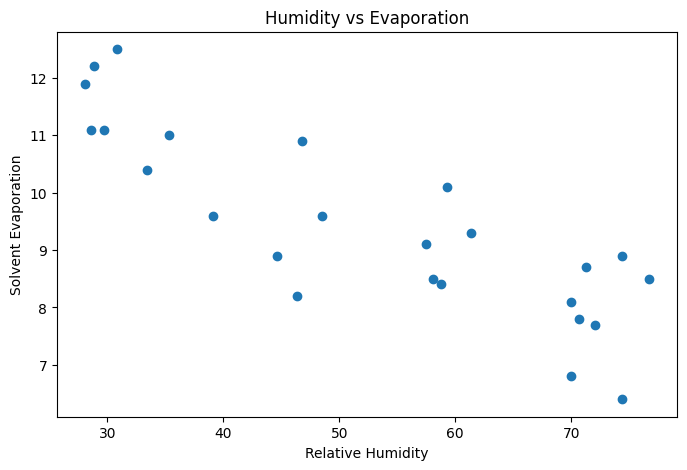

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(df["Humidity"], df["Evaporation"])

plt.xlabel("Relative Humidity")
plt.ylabel("Solvent Evaporation")

plt.title("Humidity vs Evaporation")

plt.show()

In [17]:
x = df["Humidity"].values
y = df["Evaporation"].values

x_mean = np.mean(x)
y_mean = np.mean(y)

a1 = np.sum((x-x_mean)*(y-y_mean)) / np.sum((x-x_mean)**2)
a0 = y_mean - a1*x_mean

print("Slope (a1):",a1)
print("Intercept (a0):",a0)

Slope (a1): -0.08006059146778506
Intercept (a0): 13.63886686883962


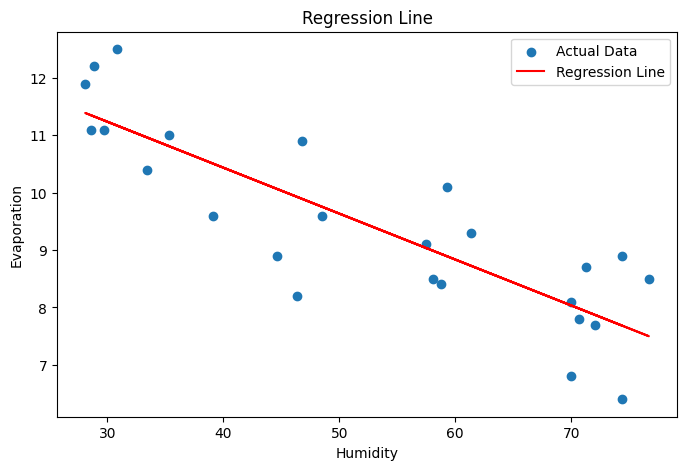

In [18]:
y_pred = a0 + a1*x

plt.figure(figsize=(8,5))

plt.scatter(x,y,label="Actual Data")
plt.plot(x,y_pred,color='red',label="Regression Line")

plt.xlabel("Humidity")
plt.ylabel("Evaporation")

plt.title("Regression Line")

plt.legend()
plt.show()

In [19]:
SSE = np.sum((y - y_pred)**2)

print("SSE =",SSE)

SSE = 18.060739189837225


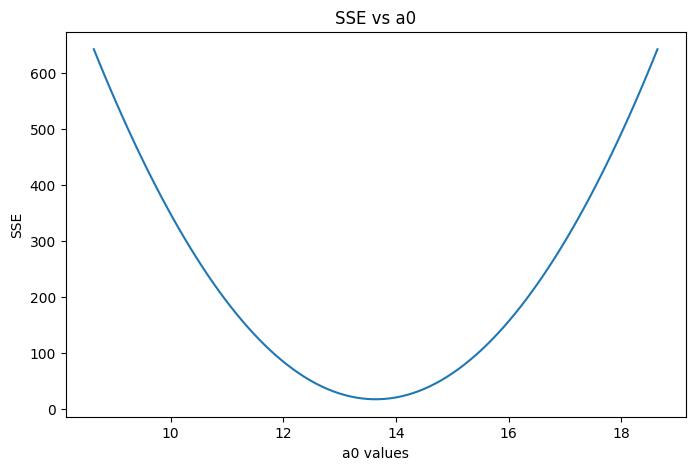

In [20]:
a0_values = np.linspace(a0-5, a0+5, 100)

sse_a0 = []

for i in a0_values:

    y_temp = i + a1*x

    sse = np.sum((y-y_temp)**2)

    sse_a0.append(sse)

plt.figure(figsize=(8,5))

plt.plot(a0_values,sse_a0)

plt.xlabel("a0 values")
plt.ylabel("SSE")

plt.title("SSE vs a0")

plt.show()

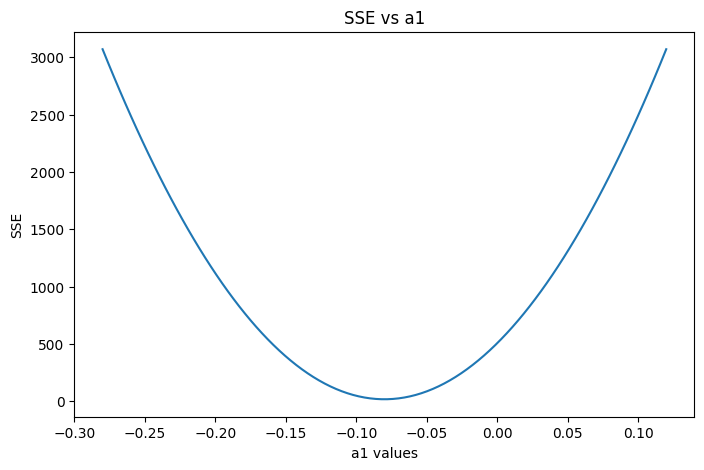

In [21]:
a1_values = np.linspace(a1-0.2, a1+0.2, 100)

sse_a1 = []

for i in a1_values:

    y_temp = a0 + i*x

    sse = np.sum((y-y_temp)**2)

    sse_a1.append(sse)

plt.figure(figsize=(8,5))

plt.plot(a1_values,sse_a1)

plt.xlabel("a1 values")
plt.ylabel("SSE")

plt.title("SSE vs a1")

plt.show()

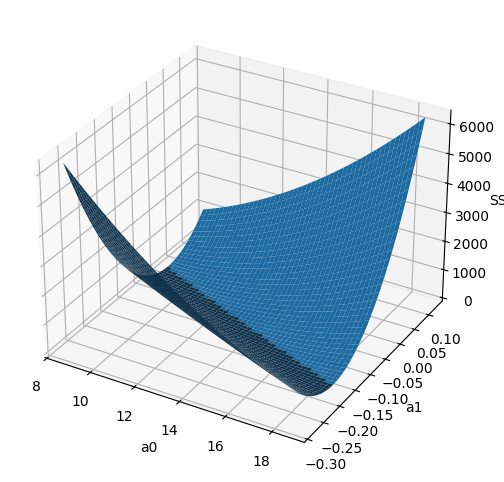

In [22]:
from mpl_toolkits.mplot3d import Axes3D

a0_range = np.linspace(a0-5,a0+5,50)
a1_range = np.linspace(a1-0.2,a1+0.2,50)

A0,A1 = np.meshgrid(a0_range,a1_range)

SSE_surface = np.zeros(A0.shape)

for i in range(len(a0_range)):
    for j in range(len(a1_range)):

        y_temp = A0[i,j] + A1[i,j]*x

        SSE_surface[i,j] = np.sum((y-y_temp)**2)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')

ax.plot_surface(A0,A1,SSE_surface)

ax.set_xlabel("a0")
ax.set_ylabel("a1")
ax.set_zlabel("SSE")

plt.show()

In [23]:
a0_gd = 0
a1_gd = 0

learning_rate = 0.0001
epochs = 1000

n = len(x)

for i in range(epochs):

    y_pred = a0_gd + a1_gd*x

    da0 = (-2/n)*np.sum(y-y_pred)
    da1 = (-2/n)*np.sum((y-y_pred)*x)

    a0_gd = a0_gd - learning_rate*da0
    a1_gd = a1_gd - learning_rate*da1

print("Gradient Descent a0:",a0_gd)
print("Gradient Descent a1:",a1_gd)

Gradient Descent a0: 0.2557581145008114
Gradient Descent a1: 0.1505556942195959


In [24]:
X = np.vstack([np.ones(len(x)),x]).T

beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("Matrix Method a0:",beta[0])
print("Matrix Method a1:",beta[1])

Matrix Method a0: 13.638866868839587
Matrix Method a1: -0.08006059146778409


In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

x_reshape = x.reshape(-1,1)

model.fit(x_reshape,y)

print("Library Intercept:",model.intercept_)
print("Library Slope:",model.coef_[0])

Library Intercept: 13.63886686883962
Library Slope: -0.08006059146778506


In [26]:
y_pred_lib = model.predict(x_reshape)

mse = mean_squared_error(y,y_pred_lib)
mae = mean_absolute_error(y,y_pred_lib)
rmse = np.sqrt(mse)
r2 = r2_score(y,y_pred_lib)

print("R2 Score:",r2)
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse)

R2 Score: 0.7173168552734491
MSE: 0.722429567593489
MAE: 0.7049925127232683
RMSE: 0.8499585681628775


# Que 3

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
data3 = {
"Crack":[2,9,5,10,3,3,8,7,8,5],
"Permeability":[2.1,8.4,5.1,14.5,4.4,6.2,12.5,7.0,17.2,7.1],
"Fracture":[4.31,22.11,11.40,24.15,6.21,5.65,9.71,12.00,14.25,8.63]
}

df = pd.DataFrame(data3)
df

,Crack,Permeability,Fracture
0,2,2.1,4.31
1,9,8.4,22.11
2,5,5.1,11.40
3,10,14.5,24.15
4,3,4.4,6.21
5,3,6.2,5.65
6,8,12.5,9.71
7,7,7.0,12.00
8,8,17.2,14.25
9,5,7.1,8.63


In [29]:
x1 = df["Permeability"].values
x2 = df["Fracture"].values
y = df["Crack"].values

In [30]:
X = np.column_stack((np.ones(len(x1)), x1, x2))

beta = np.linalg.inv(X.T @ X) @ X.T @ y

print("Intercept (a0):",beta[0])
print("Slope a1 (Permeability):",beta[1])
print("Slope a2 (Fracture Energy):",beta[2])

Intercept (a0): 0.8046744972685398
Slope a1 (Permeability): 0.24521108935916924
Slope a2 (Fracture Energy): 0.26374698510779215


In [31]:
a0 = beta[0]
a1 = beta[1]
a2 = beta[2]

print("Regression Equation:")
print("Crack =",a0,"+",a1,"* Permeability +",a2,"* Fracture")

Regression Equation:
Crack = 0.8046744972685398 + 0.24521108935916924 * Permeability + 0.26374698510779215 * Fracture


In [32]:
y_pred = a0 + a1*x1 + a2*x2

y_pred

array([ 2.45636729,  8.69589349,  5.06196668, 10.72972498,  3.52147207,
        3.81515372,  6.43079634,  5.68611594,  8.78069977,  4.82180971])

In [33]:
SSE = np.sum((y - y_pred)**2)

print("SSE =",SSE)

SSE = 6.603434348120021


In [36]:
a0_gd = 0
a1_gd = 0
a2_gd = 0

learning_rate = 0.001
epochs = 1000

n = len(y)

for i in range(epochs):

    y_pred = a0_gd + a1_gd*x1 + a2_gd*x2

    da0 = (-2/n)*np.sum(y-y_pred)
    da1 = (-2/n)*np.sum((y-y_pred)*x1)
    da2 = (-2/n)*np.sum((y-y_pred)*x2)

    a0_gd = a0_gd - learning_rate*da0
    a1_gd = a1_gd - learning_rate*da1
    a2_gd = a2_gd - learning_rate*da2

print("Grad Descent ")
print("a0:",a0_gd)
print("a1:",a1_gd)
print("a2:",a2_gd)

Grad Descent 
a0: 0.26848207988990846
a1: 0.27104036591847686
a2: 0.28207892717752414


In [37]:
X_lib = df[["Permeability","Fracture"]]
y_lib = df["Crack"]

model = LinearRegression()

model.fit(X_lib,y_lib)

print("Intercept:",model.intercept_)
print("Slope Permeability:",model.coef_[0])
print("Slope Fracture:",model.coef_[1])

Intercept: 0.804674497268552
Slope Permeability: 0.24521108935916858
Slope Fracture: 0.26374698510779215


In [38]:
y_pred_lib = model.predict(X_lib)

y_pred_lib

array([ 2.45636729,  8.69589349,  5.06196668, 10.72972498,  3.52147207,
        3.81515372,  6.43079634,  5.68611594,  8.78069977,  4.82180971])

In [39]:
mse = mean_squared_error(y_lib,y_pred_lib)
mae = mean_absolute_error(y_lib,y_pred_lib)
rmse = np.sqrt(mse)
r2 = r2_score(y_lib,y_pred_lib)

print("R2 Score:",r2)
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse)

R2 Score: 0.9056652235982855
MSE: 0.6603434348120019
MAE: 0.6730769028902397
RMSE: 0.8126151824892284


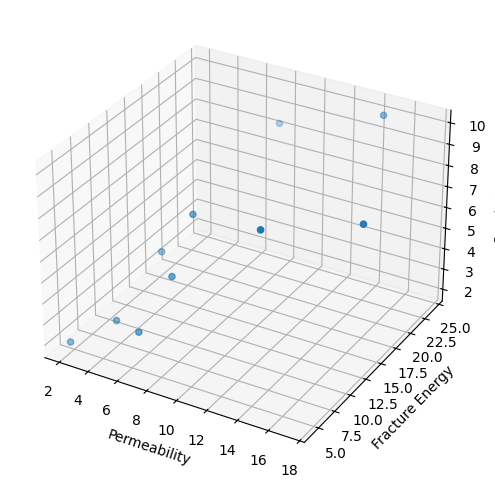

In [42]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection='3d')

ax.scatter(x1,x2,y)

ax.set_xlabel("Permeability")
ax.set_ylabel("Fracture Energy")
ax.set_zlabel("Crack Rating")

plt.show()